# Training the RL--GNN Decoder

This notebook is the training and hyperparameter-search stage. Its purpose is to find a useful RL--GNN model configuration before running the heavier QEC diagnostics in `tests.ipynb`.

The workflow is:

1. Build a small/medium BB-code training task.
2. Warm-start the GNN by imitating an exact low-weight lookup teacher.
3. Fine-tune with actor--critic reinforcement learning.
4. Compare hyperparameter configurations using held-out error rates.
5. Save the best configuration for `tests.ipynb`.

The figures are intentionally one-column friendly: each plot is a single figure or heatmap.


In [78]:
import itertools
import json
import sys
import time
import importlib
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.sparse import csr_matrix, hstack

PROJECT_CODE = Path.cwd().resolve()
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import utils
utils = importlib.reload(utils)

plt.style.use("seaborn-v0_8-whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"utils.py: {utils.__file__}")


Device: cpu
utils.py: C:\Users\Jogga\Documents\V26\FYS5429\Project\Code\utils.py


## 1. Training setup

The default `expanded` budget searches a wider hyperparameter space than the quick notebook version: hidden dimension, GNN depth, learning rate, and entropy regularization are all varied. This makes the model-selection plots more meaningful while still keeping the experiment feasible on a normal laptop.


In [79]:
TASK = "medium-bb-lite"    # "small-bb" or "medium-bb-lite"
BUDGET = "expanded"        # "quick", "expanded", or "standard"
EVAL_EPISODES = 40          # validation episodes per search error rate
OUTPUT_DIR = Path("training_results") / f"{TASK}_{BUDGET}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# tests.ipynb reads this compatibility path, so the best training result is mirrored there.
TESTS_COMPAT_CONFIG = Path("rl_tests/results_notebooks/medium-bb-lite_quick/best_config.json")
TESTS_COMPAT_CONFIG.parent.mkdir(parents=True, exist_ok=True)


## 2. Code Construction

The training task uses a BB-code parity-check matrix. For CSS decoding we train one channel at a time; here the hyperparameter search uses `Hx`, corresponding to Z-error correction. The same architecture is later reused for both CSS channels in `tests.ipynb`.


In [80]:
def bb_shift_matrix(l, m, x_pow, y_pow):
    rows, cols = [], []
    for x in range(l):
        for y in range(m):
            src = x * m + y
            dst = ((x + x_pow) % l) * m + ((y + y_pow) % m)
            rows.append(dst)
            cols.append(src)
    return csr_matrix((np.ones(l * m, dtype=np.uint8), (rows, cols)), shape=(l * m, l * m), dtype=np.uint8)


def bb_polynomial_matrix(l, m, terms):
    matrix = csr_matrix((l * m, l * m), dtype=np.uint8)
    for x_pow, y_pow in terms:
        matrix += bb_shift_matrix(l, m, x_pow, y_pow)
    matrix.data %= 2
    matrix.eliminate_zeros()
    return matrix


def bivariate_bicycle_code(l, m):
    a = bb_polynomial_matrix(l, m, [(3, 0), (0, 1), (0, 2)])
    b = bb_polynomial_matrix(l, m, [(0, 3), (1, 0), (2, 0)])
    hx = hstack([a, b], format="csr", dtype=np.uint8)
    hz = hstack([b.T, a.T], format="csr", dtype=np.uint8)
    return hx, hz


def task_matrix(task):
    if task == "small-bb":
        hx, _ = bivariate_bicycle_code(4, 4)
        return hx, [0.01, 0.03, 0.05], 8
    if task == "medium-bb-lite":
        hx, _ = bivariate_bicycle_code(6, 6)
        return hx, [0.005, 0.015, 0.03], 10
    raise ValueError(task)

check_matrix, eval_p_errors, default_max_steps = task_matrix(TASK)
code_summary = pd.DataFrame([{
    "task": TASK,
    "check matrix shape": check_matrix.shape,
    "physical qubits": check_matrix.shape[1],
    "checks": check_matrix.shape[0],
    "column weights": sorted(set(check_matrix.getnnz(axis=0).tolist())),
    "row weights": sorted(set(check_matrix.getnnz(axis=1).tolist())),
    "evaluation error rates": eval_p_errors,
}])
display(code_summary)


,task,check matrix shape,physical qubits,checks,column weights,row weights,evaluation error rates
0,medium-bb-lite,"(36, 72)",72,36,[3],[6],"[0.005, 0.015, 0.03]"


## 3. Hyperparameter search space

The expanded search varies four important knobs: graph width, graph depth, optimizer step size, and exploration pressure. The table is intentionally shown before training so it is clear how many models are being compared.


In [81]:
@dataclass(frozen=True)
class TrainConfig:
    name: str
    hidden_dim: int = 48
    layers: int = 3
    lr: float = 7e-4
    imitation_batches: int = 30
    imitation_batch_size: int = 16
    rl_episodes: int = 60
    gamma: float = 0.97
    entropy_coef: float = 0.005
    value_coef: float = 0.5
    max_steps: int = 10
    p_train: float = 0.04
    min_train_weight: int = 1
    max_train_weight: int = 2
    teacher: str = "exact"
    seed: int = 0


def candidate_configs(task, budget):
    if budget == "quick":
        base = TrainConfig(name="base", max_steps=default_max_steps)
        grid = {
            "hidden_dim": [48, 64],
            "layers": [2, 3],
            "lr": [7e-4, 1e-3],
            "entropy_coef": [0.005],
        }
    elif budget == "expanded":
        base = TrainConfig(
            name="base",
            imitation_batches=45,
            imitation_batch_size=18,
            rl_episodes=90,
            max_steps=max(default_max_steps, 12),
        )
        grid = {
            "hidden_dim": [32, 48, 64, 96],
            "layers": [2, 3, 4],
            "lr": [3e-4, 7e-4],
            "entropy_coef": [0.001, 0.005],
        }
    elif budget == "standard":
        base = TrainConfig(
            name="base",
            hidden_dim=64,
            layers=3,
            imitation_batches=80,
            imitation_batch_size=24,
            rl_episodes=160,
            max_steps=max(default_max_steps, 14),
        )
        grid = {
            "hidden_dim": [48, 64, 96, 128],
            "layers": [2, 3, 4, 5],
            "lr": [3e-4, 7e-4, 1e-3],
            "entropy_coef": [0.001, 0.005, 0.01],
        }
    else:
        raise ValueError(budget)

    keys = list(grid)
    for idx, values in enumerate(itertools.product(*(grid[key] for key in keys))):
        updates = dict(zip(keys, values))
        yield replace(base, name=f"{task}_{budget}_{idx:03d}", seed=1000 + idx, **updates)

configs = list(candidate_configs(TASK, BUDGET))
config_table = pd.DataFrame([asdict(c) for c in configs])
display(config_table)
print(f"Training {len(configs)} candidate models.")


,name,hidden_dim,layers,lr,imitation_batches,imitation_batch_size,rl_episodes,gamma,entropy_coef,value_coef,max_steps,p_train,min_train_weight,max_train_weight,teacher,seed
0,medium-bb-lite_expanded_000,32,2,0.0003,45,18,90,0.97,0.001,0.5,12,0.04,1,2,exact,1000
1,medium-bb-lite_expanded_001,32,2,0.0003,45,18,90,0.97,0.005,0.5,12,0.04,1,2,exact,1001
2,medium-bb-lite_expanded_002,32,2,0.0007,45,18,90,0.97,0.001,0.5,12,0.04,1,2,exact,1002
3,medium-bb-lite_expanded_003,32,2,0.0007,45,18,90,0.97,0.005,0.5,12,0.04,1,2,exact,1003
4,medium-bb-lite_expanded_004,32,3,0.0003,45,18,90,0.97,0.001,0.5,12,0.04,1,2,exact,1004
5,medium-bb-lite_expanded_005,32,3,0.0003,45,18,90,0.97,0.005,0.5,12,0.04,1,2,exact,1005
6,medium-bb-lite_expanded_006,32,3,0.0007,45,18,90,0.97,0.001,0.5,12,0.04,1,2,exact,1006
7,medium-bb-lite_expanded_007,32,3,0.0007,45,18,90,0.97,0.005,0.5,12,0.04,1,2,exact,1007
8,medium-bb-lite_expanded_008,32,4,0.0003,45,18,90,0.97,0.001,0.5,12,0.04,1,2,exact,1008
9,medium-bb-lite_expanded_009,32,4,0.0003,45,18,90,0.97,0.005,0.5,12,0.04,1,2,exact,1009


Training 48 candidate models.


## 4. Exact Low-Weight Teacher

The GNN is not started from random behavior alone. First, it imitates an exact low-weight lookup teacher. This teacher enumerates all component errors up to weight 2 and stores one minimum-weight correction for each syndrome.

This warm-start is important because pure RL can learn slowly or discover bad shortcuts before it ever sees good correction behavior.


In [82]:
def syndrome_key(syndrome):
    return np.packbits(syndrome.astype(np.uint8)).tobytes()


def build_min_weight_lookup(check_matrix, max_weight=2):
    h = utils.to_csr_binary(check_matrix)
    lookup = {syndrome_key(np.zeros(h.shape[0], dtype=np.uint8)): tuple()}
    collisions = 0
    for weight in range(1, max_weight + 1):
        for support in itertools.combinations(range(h.shape[1]), weight):
            syn = np.asarray(h[:, support].sum(axis=1)).ravel().astype(np.uint8) % 2
            key = syndrome_key(syn)
            if key in lookup:
                collisions += 1
            else:
                lookup[key] = tuple(int(q) for q in support)
    return lookup, collisions


def exact_teacher_action(env, lookup):
    if int(env.syndrome.sum()) == 0:
        return env.stop_action
    support = lookup.get(syndrome_key(env.syndrome))
    if not support:
        return utils.choose_greedy_syndrome_reducing_action(env)
    return int(support[0])

lookup, lookup_collisions = build_min_weight_lookup(check_matrix, max_weight=2)
display(pd.DataFrame([{
    "stored syndromes": len(lookup),
    "collisions while building": lookup_collisions,
    "teacher max component weight": 2,
}]))


,stored syndromes,collisions while building,teacher max component weight
0,2629,0,2


## 5. Training and Evaluation Functions

The functions below train one configuration and evaluate it on held-out error rates. The evaluation reports syndrome-clearing success, exact residual-zero rate, residual component weight, and episode length.


In [83]:
def bounded_sampler(p_error, min_weight, max_weight):
    def sampler(n_qubits, rng):
        return utils.random_component_error(n_qubits, rng, p=p_error, min_weight=min_weight, max_weight=max_weight)
    return sampler


def make_env(config):
    return utils.CSSCorrectionEnv(
        check_matrix,
        max_steps=config.max_steps,
        error_sampler=bounded_sampler(config.p_train, config.min_train_weight, config.max_train_weight),
        p_error=config.p_train,
        seed=config.seed,
        step_penalty=-0.03,
        flip_reward_scale=0.35,
        success_reward=4.0,
        failure_reward=-2.0,
        allow_stop_when_nonzero=False,
    )


def train_exact_imitation(env, model, optimizer, lookup, batches, batch_size):
    rows = []
    for batch in range(batches):
        losses, hits = [], []
        for _ in range(batch_size):
            env.reset()
            for _step in range(env.max_steps):
                target = exact_teacher_action(env, lookup)
                logits, _ = model(env.node_features(DEVICE), env.action_mask(DEVICE))
                target_tensor = torch.tensor([target], dtype=torch.long, device=DEVICE)
                losses.append(torch.nn.functional.cross_entropy(logits.view(1, -1), target_tensor))
                hits.append(float(torch.argmax(logits).item() == target))
                _, _, done, _ = env.step(target)
                if done:
                    break
        loss = torch.stack(losses).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        rows.append({"batch": batch, "imitation_loss": float(loss.detach().cpu()), "teacher_action_accuracy": float(np.mean(hits))})
    return pd.DataFrame(rows)


@torch.no_grad()
def evaluate_model(model, config, p_error, episodes, seed):
    h = utils.to_csr_binary(check_matrix)
    rng = np.random.default_rng(seed)
    rows = []
    for episode in range(episodes):
        error = utils.random_component_error(h.shape[1], rng, p=p_error, min_weight=0, max_weight=None)
        env = utils.CSSCorrectionEnv(h, max_steps=config.max_steps, seed=seed + episode, allow_stop_when_nonzero=False)
        env.reset(error=error)
        done = False
        steps = 0
        while not done:
            action = model.greedy_action(env.node_features(DEVICE), env.action_mask(DEVICE))
            _, _, done, _ = env.step(action)
            steps += 1
        residual = (env.error + env.correction) % 2
        rows.append({
            "p_error": p_error,
            "success": int(env.syndrome.sum()) == 0,
            "exact": int(residual.sum()) == 0,
            "residual_weight": int(residual.sum()),
            "final_syndrome_weight": int(env.syndrome.sum()),
            "steps": steps,
            "initial_error_weight": int(error.sum()),
        })
    return pd.DataFrame(rows)


def train_and_score(config):
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    env = make_env(config)
    model = utils.GraphActorCritic(env.graph, hidden_dim=config.hidden_dim, num_layers=config.layers).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    start = time.perf_counter()
    imitation_history = train_exact_imitation(env, model, optimizer, lookup, config.imitation_batches, config.imitation_batch_size)
    rl_history = pd.DataFrame(utils.train_actor_critic(
        env, model, optimizer,
        episodes=config.rl_episodes,
        gamma=config.gamma,
        value_coef=config.value_coef,
        entropy_coef=config.entropy_coef,
        grad_clip=1.0,
        device=DEVICE,
    ))
    train_seconds = time.perf_counter() - start

    eval_frames = []
    for i, p_error in enumerate(eval_p_errors):
        eval_frames.append(evaluate_model(model, config, p_error, EVAL_EPISODES, config.seed + 10_000 + i))
    eval_df = pd.concat(eval_frames, ignore_index=True)

    score = eval_df["success"].mean() - 0.15 * eval_df["residual_weight"].mean() - 0.01 * eval_df["steps"].mean()
    result = {
        **asdict(config),
        "score": float(score),
        "mean_success_rate": float(eval_df["success"].mean()),
        "mean_exact_rate": float(eval_df["exact"].mean()),
        "mean_residual_weight": float(eval_df["residual_weight"].mean()),
        "mean_final_syndrome_weight": float(eval_df["final_syndrome_weight"].mean()),
        "mean_steps": float(eval_df["steps"].mean()),
        "final_imitation_accuracy": float(imitation_history["teacher_action_accuracy"].iloc[-1]),
        "final_rl_success": float(rl_history["success"].iloc[-1]),
        "train_seconds": float(train_seconds),
    }
    return result, eval_df, imitation_history, rl_history, model


## 6. Run the Hyperparameter Search

The search trains each candidate model, evaluates it on held-out noise rates, and saves a ranked table. The best configuration is also exported for `tests.ipynb`.


In [84]:
results = []
evaluation_tables = []
imitation_histories = []
rl_histories = []
models = {}

for index, config in enumerate(configs, start=1):
    print(f"[{index}/{len(configs)}] training {config.name}: hidden={config.hidden_dim}, layers={config.layers}, lr={config.lr}")
    result, eval_df, imitation_history, rl_history, model = train_and_score(config)
    eval_df["config_name"] = config.name
    imitation_history["config_name"] = config.name
    rl_history["config_name"] = config.name

    results.append(result)
    evaluation_tables.append(eval_df)
    imitation_histories.append(imitation_history)
    rl_histories.append(rl_history)
    models[config.name] = model

    ranked_so_far = pd.DataFrame(results).sort_values("score", ascending=False)
    ranked_so_far.to_csv(OUTPUT_DIR / "search_results.csv", index=False)
    pd.concat(evaluation_tables, ignore_index=True).to_csv(OUTPUT_DIR / "evaluation_by_rate.csv", index=False)
    best_so_far = ranked_so_far.iloc[0].to_dict()
    (OUTPUT_DIR / "best_config.json").write_text(json.dumps(best_so_far, indent=2), encoding="utf-8")
    if TASK == "medium-bb-lite":
        TESTS_COMPAT_CONFIG.write_text(json.dumps(best_so_far, indent=2), encoding="utf-8")

    print(f"  score={result['score']:.3f}, success={result['mean_success_rate']:.3f}, exact={result['mean_exact_rate']:.3f}, residual={result['mean_residual_weight']:.3f}, seconds={result['train_seconds']:.1f}")

ranked_results = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
evaluation_by_rate = pd.concat(evaluation_tables, ignore_index=True)
imitation_all = pd.concat(imitation_histories, ignore_index=True)
rl_all = pd.concat(rl_histories, ignore_index=True)
best_config = ranked_results.iloc[0].to_dict()
best_name = best_config["name"]

# Final write after the loop: this prevents sidecar files from being left at a partial checkpoint.
ranked_results.to_csv(OUTPUT_DIR / "search_results.csv", index=False)
evaluation_by_rate.to_csv(OUTPUT_DIR / "evaluation_by_rate.csv", index=False)
(OUTPUT_DIR / "best_config.json").write_text(json.dumps(best_config, indent=2), encoding="utf-8")
if TASK == "medium-bb-lite":
    TESTS_COMPAT_CONFIG.write_text(json.dumps(best_config, indent=2), encoding="utf-8")

display(ranked_results)
print(f"Best config: {best_name}")
print(f"Saved results to: {OUTPUT_DIR}")


[1/48] training medium-bb-lite_expanded_000: hidden=32, layers=2, lr=0.0003
  score=0.912, success=0.983, exact=0.958, residual=0.342, seconds=12.0
[2/48] training medium-bb-lite_expanded_001: hidden=32, layers=2, lr=0.0003
  score=0.909, success=0.992, exact=0.933, residual=0.425, seconds=10.8
[3/48] training medium-bb-lite_expanded_002: hidden=32, layers=2, lr=0.0007
  score=0.912, success=1.000, exact=0.942, residual=0.467, seconds=7.0
[4/48] training medium-bb-lite_expanded_003: hidden=32, layers=2, lr=0.0007
  score=0.897, success=0.992, exact=0.942, residual=0.517, seconds=7.4
[5/48] training medium-bb-lite_expanded_004: hidden=32, layers=3, lr=0.0003
  score=0.940, success=0.975, exact=0.967, residual=0.117, seconds=12.6
[6/48] training medium-bb-lite_expanded_005: hidden=32, layers=3, lr=0.0003
  score=0.829, success=0.908, exact=0.908, residual=0.375, seconds=15.3
[7/48] training medium-bb-lite_expanded_006: hidden=32, layers=3, lr=0.0007
  score=0.780, success=0.883, exact=0.

,name,hidden_dim,layers,lr,imitation_batches,imitation_batch_size,rl_episodes,gamma,entropy_coef,value_coef,...,seed,score,mean_success_rate,mean_exact_rate,mean_residual_weight,mean_final_syndrome_weight,mean_steps,final_imitation_accuracy,final_rl_success,train_seconds
0,medium-bb-lite_expanded_018,48,3,0.0007,45,18,90,0.97,0.001,0.5,...,1018,0.961333,1.000000,0.975000,0.150000,0.000000,1.616667,0.914286,0.0,11.913624
1,medium-bb-lite_expanded_014,48,2,0.0007,45,18,90,0.97,0.001,0.5,...,1014,0.947583,0.983333,0.975000,0.125000,0.058333,1.700000,0.903226,1.0,8.615843
2,medium-bb-lite_expanded_045,96,4,0.0003,45,18,90,0.97,0.005,0.5,...,1045,0.946250,1.000000,0.966667,0.250000,0.000000,1.625000,0.906250,1.0,21.948907
3,medium-bb-lite_expanded_004,32,3,0.0003,45,18,90,0.97,0.001,0.5,...,1004,0.940000,0.975000,0.966667,0.116667,0.083333,1.750000,0.800000,0.0,12.622328
4,medium-bb-lite_expanded_037,96,2,0.0003,45,18,90,0.97,0.005,0.5,...,1037,0.931250,0.975000,0.975000,0.175000,0.108333,1.750000,1.000000,0.0,12.218629
5,medium-bb-lite_expanded_016,48,3,0.0003,45,18,90,0.97,0.001,0.5,...,1016,0.926583,1.000000,0.958333,0.383333,0.000000,1.591667,0.882353,1.0,11.541115
6,medium-bb-lite_expanded_034,64,4,0.0007,45,18,90,0.97,0.001,0.5,...,1034,0.925833,1.000000,0.950000,0.383333,0.000000,1.666667,0.757576,0.0,18.497409
7,medium-bb-lite_expanded_017,48,3,0.0003,45,18,90,0.97,0.005,0.5,...,1017,0.920000,1.000000,0.958333,0.416667,0.000000,1.750000,0.870968,1.0,11.960340
8,medium-bb-lite_expanded_036,96,2,0.0003,45,18,90,0.97,0.001,0.5,...,1036,0.917750,0.991667,0.941667,0.375000,0.025000,1.766667,1.000000,1.0,12.383740
9,medium-bb-lite_expanded_047,96,4,0.0007,45,18,90,0.97,0.005,0.5,...,1047,0.916583,0.966667,0.958333,0.216667,0.116667,1.758333,0.939394,0.0,29.692550


Best config: medium-bb-lite_expanded_018
Saved results to: training_results\medium-bb-lite_expanded


## 7. Ranking Plot

This first figure answers the basic question: which hyperparameter setting was best according to the combined score?


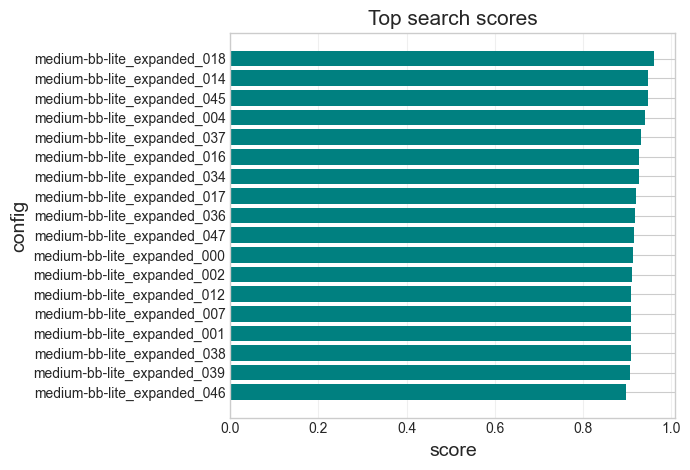

In [111]:
plot_df = ranked_results.sort_values("score", ascending=True)
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.barh(plot_df["name"].tail(18), plot_df["score"].tail(18), color="teal")
ax.set_title("Top search scores", fontsize=15)
ax.set_xlabel("score", fontsize=14)
ax.set_ylabel("config", fontsize=14)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Heatmap: Architecture Choice

This heatmap groups configurations by hidden dimension and number of message-passing layers. It helps show whether the best result came from a larger model or simply from noise in one training run.


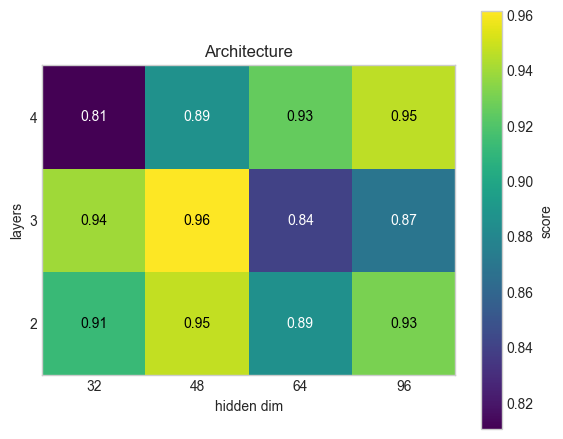

In [110]:
heatmap_data = ranked_results.pivot_table(
    index="layers",
    columns="hidden_dim",
    values="score",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(5.8, 4.5))
image = ax.imshow(heatmap_data.values, origin="lower", cmap="viridis")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("hidden dim")
ax.set_ylabel("layers")
ax.set_title("Architecture")

# Remove visible cell grid lines.
ax.grid(False)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.values[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < heatmap_data.values.mean() else "black",
        )

fig.colorbar(image, ax=ax, label="score")
plt.tight_layout()
plt.show()



## 6b. Optimizer choices

This heatmap isolates the training knobs. Each cell shows the best score reached by any architecture using that learning rate and entropy coefficient.


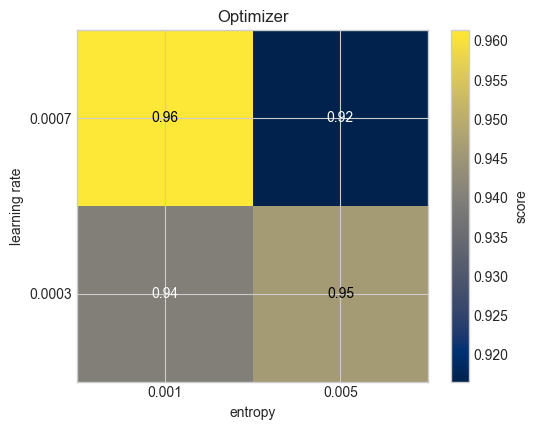

In [87]:
optimizer_heatmap = ranked_results.pivot_table(index="lr", columns="entropy_coef", values="score", aggfunc="max").sort_index()
fig, ax = plt.subplots(figsize=(5.6, 4.4))
image = ax.imshow(optimizer_heatmap.values, origin="lower", cmap="cividis")
ax.set_xticks(range(len(optimizer_heatmap.columns)))
ax.set_xticklabels([f"{v:g}" for v in optimizer_heatmap.columns])
ax.set_yticks(range(len(optimizer_heatmap.index)))
ax.set_yticklabels([f"{v:g}" for v in optimizer_heatmap.index])
ax.set_title("Optimizer")
ax.set_xlabel("entropy")
ax.set_ylabel("learning rate")
for i in range(optimizer_heatmap.shape[0]):
    for j in range(optimizer_heatmap.shape[1]):
        value = optimizer_heatmap.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value < optimizer_heatmap.values.mean() else "black")
fig.colorbar(image, ax=ax, label="score")
plt.tight_layout()
plt.show()


## 6c. One-dimensional parameter effects

The plot below shows the best score obtained at each value of each hyperparameter. It is not a causal proof, but it is a compact way to see which regions of the search space were promising.


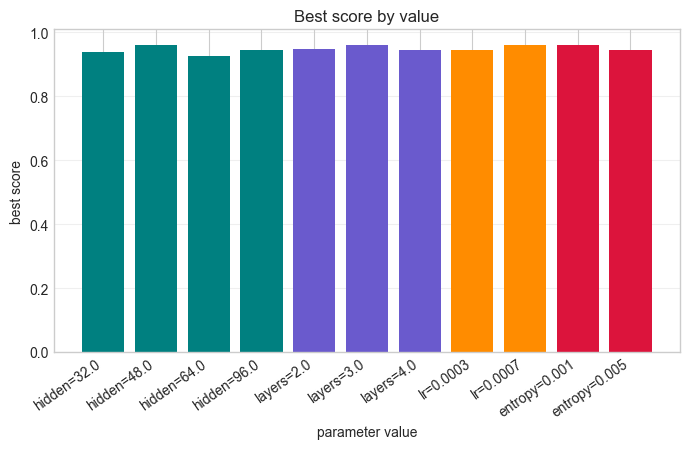

In [88]:
effect_rows = []
for column, label in [
    ("hidden_dim", "hidden"),
    ("layers", "layers"),
    ("lr", "lr"),
    ("entropy_coef", "entropy"),
]:
    temp = ranked_results.groupby(column, as_index=False)["score"].max()
    for _, row in temp.iterrows():
        effect_rows.append({"parameter": label, "value": str(row[column]), "best_score": row["score"]})
effect_df = pd.DataFrame(effect_rows)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
positions = np.arange(len(effect_df))
colors = effect_df["parameter"].map({"hidden": "teal", "layers": "slateblue", "lr": "darkorange", "entropy": "crimson"})
ax.bar(positions, effect_df["best_score"], color=colors)
ax.set_xticks(positions)
ax.set_xticklabels(effect_df["parameter"] + "=" + effect_df["value"], rotation=35, ha="right")
ax.set_title("Best score by value")
ax.set_xlabel("parameter value")
ax.set_ylabel("best score")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Best Model: Evaluation by Noise Rate

A good model should not only have a high average score; it should also remain stable as the physical error probability changes.


,p_error,success_rate,exact_rate,mean_residual_weight,mean_steps,mean_initial_error_weight
0,0.005,1.0,1.000,0.00,1.000,0.275
1,0.015,1.0,0.950,0.30,1.475,1.050
2,0.030,1.0,0.975,0.15,2.375,2.225


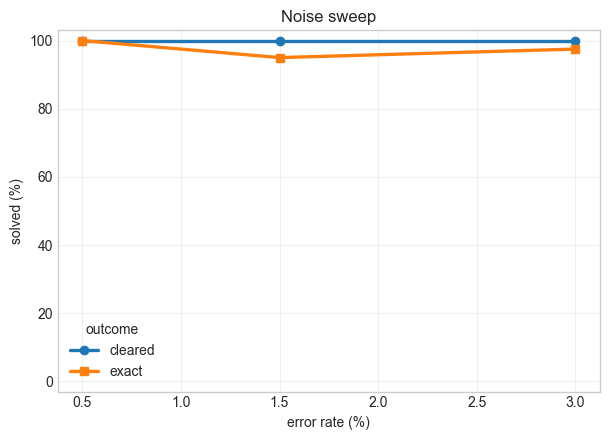

In [89]:
best_eval = evaluation_by_rate[evaluation_by_rate["config_name"] == best_name].copy()
best_eval_summary = best_eval.groupby("p_error", as_index=False).agg(
    success_rate=("success", "mean"),
    exact_rate=("exact", "mean"),
    mean_residual_weight=("residual_weight", "mean"),
    mean_steps=("steps", "mean"),
    mean_initial_error_weight=("initial_error_weight", "mean"),
)
display(best_eval_summary)

fig, ax = plt.subplots(figsize=(6.2, 4.5))
ax.plot(best_eval_summary["p_error"] * 100, 100 * best_eval_summary["success_rate"], marker="o", linewidth=2.4, label="cleared")
ax.plot(best_eval_summary["p_error"] * 100, 100 * best_eval_summary["exact_rate"], marker="s", linewidth=2.4, label="exact")
ax.set_title("Noise sweep")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("solved (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.3)
ax.legend(title="outcome")
plt.tight_layout()
plt.show()


## 8. Stronger validation of the selected decoder

The search above is deliberately cheap, so the next cells retest the winning model more carefully. The goal is to answer practical questions: does the correction actually clear the syndrome, does it remove the full error rather than merely hide it, and how quickly does performance degrade as the physical error rate is increased?


In [90]:
def wilson_interval(successes, total, z=1.96):
    """Return a 95% Wilson interval for a binomial success rate."""
    if total == 0:
        return np.nan, np.nan
    phat = successes / total
    denom = 1 + z**2 / total
    center = (phat + z**2 / (2 * total)) / denom
    half_width = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total) / denom
    return max(0.0, center - half_width), min(1.0, center + half_width)


best_config_object = next(config for config in configs if config.name == best_name)
best_model = models[best_name]

VALIDATION_EPISODES = 120 if BUDGET == "quick" else 300
VALIDATION_ERROR_RATES = np.array([0.0025, 0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.06])

validation_frames = []
for index, p_error in enumerate(VALIDATION_ERROR_RATES):
    validation_frames.append(evaluate_model(best_model, best_config_object, float(p_error), VALIDATION_EPISODES, 40_000 + index))

validation_trials = pd.concat(validation_frames, ignore_index=True)
summary_rows = []
for p_error, group in validation_trials.groupby("p_error"):
    lower, upper = wilson_interval(int(group["success"].sum()), len(group))
    summary_rows.append({
        "component_error_probability": p_error,
        "episodes": len(group),
        "mean_inserted_errors": group["initial_error_weight"].mean(),
        "syndrome_cleared_rate": group["success"].mean(),
        "no_residual_error_rate": group["exact"].mean(),
        "mean_residual_errors": group["residual_weight"].mean(),
        "mean_decoder_steps": group["steps"].mean(),
        "success_ci_low": lower,
        "success_ci_high": upper,
    })

validation_summary = pd.DataFrame(summary_rows)
display(validation_summary.style.format({
    "component_error_probability": "{:.3%}",
    "mean_inserted_errors": "{:.2f}",
    "syndrome_cleared_rate": "{:.1%}",
    "no_residual_error_rate": "{:.1%}",
    "mean_residual_errors": "{:.2f}",
    "mean_decoder_steps": "{:.2f}",
    "success_ci_low": "{:.1%}",
    "success_ci_high": "{:.1%}",
}))


,component_error_probability,episodes,mean_inserted_errors,syndrome_cleared_rate,no_residual_error_rate,mean_residual_errors,mean_decoder_steps,success_ci_low,success_ci_high
0,0.250%,300,0.14,100.0%,100.0%,0.00,1.01,98.7%,100.0%
1,0.500%,300,0.32,100.0%,100.0%,0.00,1.04,98.7%,100.0%
2,1.000%,300,0.77,100.0%,99.7%,0.02,1.22,98.7%,100.0%
3,1.500%,300,1.00,100.0%,100.0%,0.00,1.38,98.7%,100.0%
4,2.000%,300,1.40,100.0%,99.0%,0.07,1.66,98.7%,100.0%
5,3.000%,300,2.29,100.0%,94.7%,0.43,2.38,98.7%,100.0%
6,4.000%,300,2.88,100.0%,89.0%,0.87,2.94,98.7%,100.0%
7,6.000%,300,4.21,100.0%,71.3%,2.59,4.24,98.7%,100.0%


The next plot separates two notions of success. **Syndrome cleared** means the decoder found a correction with zero measured syndrome. **No residual error** is stricter: the proposed correction exactly cancels the sampled component error in this toy experiment.


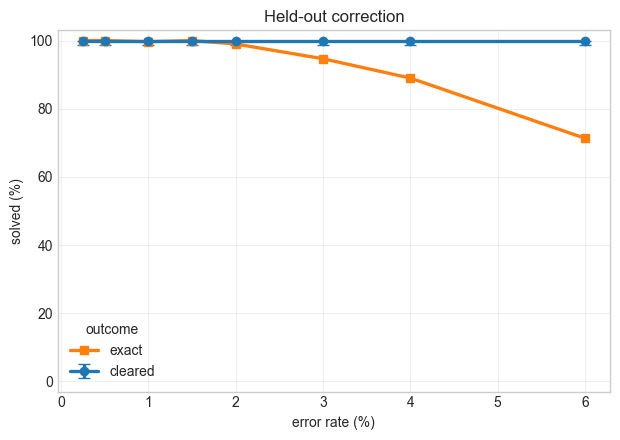

In [91]:
x = validation_summary["component_error_probability"].to_numpy() * 100
success = validation_summary["syndrome_cleared_rate"].to_numpy() * 100
success_low = validation_summary["success_ci_low"].to_numpy() * 100
success_high = validation_summary["success_ci_high"].to_numpy() * 100
exact = validation_summary["no_residual_error_rate"].to_numpy() * 100
error_low = np.maximum(0, success - success_low)
error_high = np.maximum(0, success_high - success)

fig, ax = plt.subplots(figsize=(6.3, 4.5))
ax.errorbar(
    x,
    success,
    yerr=np.vstack([error_low, error_high]),
    marker="o",
    linewidth=2.4,
    capsize=4,
    label="cleared",
)
ax.plot(x, exact, marker="s", linewidth=2.4, label="exact")
ax.set_title("Held-out correction")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("solved (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.3)
ax.legend(title="outcome")
plt.tight_layout()
plt.show()


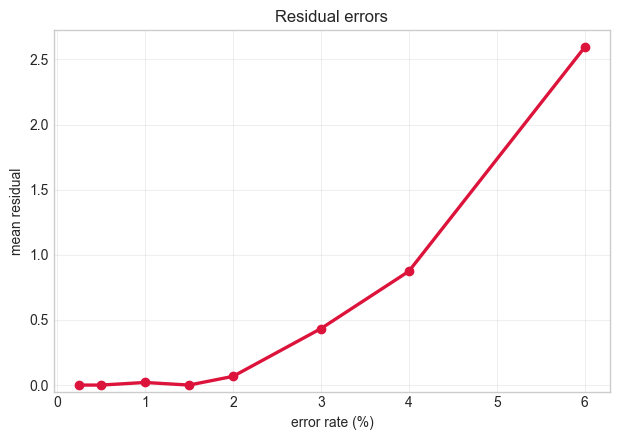

In [92]:
fig, ax = plt.subplots(figsize=(6.3, 4.5))
ax.plot(
    validation_summary["component_error_probability"] * 100,
    validation_summary["mean_residual_errors"],
    marker="o",
    linewidth=2.4,
    color="crimson",
)
ax.set_title("Residual errors")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean residual")
ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Exact-weight stress test

Random error rates mix together many error weights. Here we force the decoder to see exactly 0, 1, 2, ... inserted component errors, which makes the failure boundary easier to interpret. This is still a single CSS component channel; the full BB-code notebook applies the component decoder to both CSS sectors.


In [93]:
def sample_exact_weight_component_error(n_qubits, weight, rng):
    error = np.zeros(n_qubits, dtype=np.uint8)
    if weight > 0:
        error[rng.choice(n_qubits, size=weight, replace=False)] = 1
    return error


@torch.no_grad()
def evaluate_exact_component_weight(model, config, weight, episodes, seed):
    h = utils.to_csr_binary(check_matrix)
    rng = np.random.default_rng(seed)
    rows = []
    for episode in range(episodes):
        error = sample_exact_weight_component_error(h.shape[1], weight, rng)
        env = utils.CSSCorrectionEnv(h, max_steps=config.max_steps, seed=seed + episode, allow_stop_when_nonzero=False)
        env.reset(error=error)
        done = False
        steps = 0
        while not done:
            action = model.greedy_action(env.node_features(DEVICE), env.action_mask(DEVICE))
            _, _, done, _ = env.step(action)
            steps += 1
        residual = (env.error + env.correction) % 2
        rows.append({
            "inserted_component_errors": weight,
            "success": int(env.syndrome.sum()) == 0,
            "exact": int(residual.sum()) == 0,
            "residual_weight": int(residual.sum()),
            "final_syndrome_weight": int(env.syndrome.sum()),
            "steps": steps,
        })
    return pd.DataFrame(rows)


EXACT_WEIGHT_EPISODES = 100 if BUDGET == "quick" else 250
EXACT_WEIGHTS = list(range(0, min(8, check_matrix.shape[1] + 1)))
exact_weight_trials = pd.concat(
    [evaluate_exact_component_weight(best_model, best_config_object, weight, EXACT_WEIGHT_EPISODES, 50_000 + weight) for weight in EXACT_WEIGHTS],
    ignore_index=True,
)
exact_weight_summary = exact_weight_trials.groupby("inserted_component_errors", as_index=False).agg(
    episodes=("success", "size"),
    syndrome_cleared_rate=("success", "mean"),
    no_residual_error_rate=("exact", "mean"),
    mean_residual_errors=("residual_weight", "mean"),
    mean_final_syndrome_weight=("final_syndrome_weight", "mean"),
    mean_decoder_steps=("steps", "mean"),
)
display(exact_weight_summary.style.format({
    "syndrome_cleared_rate": "{:.1%}",
    "no_residual_error_rate": "{:.1%}",
    "mean_residual_errors": "{:.2f}",
    "mean_final_syndrome_weight": "{:.2f}",
    "mean_decoder_steps": "{:.2f}",
}))


,inserted_component_errors,episodes,syndrome_cleared_rate,no_residual_error_rate,mean_residual_errors,mean_final_syndrome_weight,mean_decoder_steps
0,0,250,100.0%,100.0%,0.00,0.00,1.00
1,1,250,100.0%,100.0%,0.00,0.00,1.00
2,2,250,100.0%,100.0%,0.00,0.00,2.00
3,3,250,100.0%,97.2%,0.17,0.00,3.00
4,4,250,100.0%,90.8%,0.67,0.00,4.05
5,5,250,100.0%,64.8%,2.68,0.00,5.17
6,6,250,100.0%,26.0%,6.50,0.00,6.22
7,7,250,100.0%,11.6%,8.85,0.00,6.95


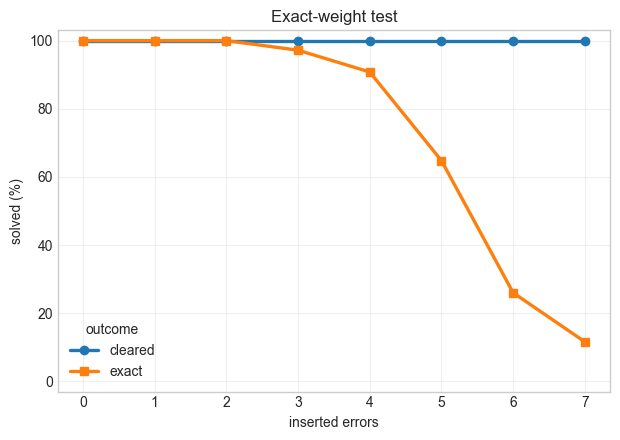

In [94]:
fig, ax = plt.subplots(figsize=(6.3, 4.5))
ax.plot(
    exact_weight_summary["inserted_component_errors"],
    100 * exact_weight_summary["syndrome_cleared_rate"],
    marker="o",
    linewidth=2.4,
    label="cleared",
)
ax.plot(
    exact_weight_summary["inserted_component_errors"],
    100 * exact_weight_summary["no_residual_error_rate"],
    marker="s",
    linewidth=2.4,
    label="exact",
)
ax.set_title("Exact-weight test")
ax.set_xlabel("inserted errors")
ax.set_ylabel("solved (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.3)
ax.legend(title="outcome")
plt.tight_layout()
plt.show()


## 10. Failure audit

A useful decoder plot should show not only that failures happen, but where they happen. The next table and plot group trials by the number of inserted component errors, so one can see whether the trained policy is mainly failing on rare high-weight patterns.


,inserted_component_errors,episodes,failure_rate,mean_residual_errors,mean_final_syndrome_weight
0,0,250,0.0%,0.00,0.00
1,1,250,0.0%,0.00,0.00
2,2,250,0.0%,0.00,0.00
3,3,250,0.0%,0.17,0.00
4,4,250,0.0%,0.67,0.00
5,5,250,0.0%,2.68,0.00
6,6,250,0.0%,6.50,0.00
7,7,250,0.0%,8.85,0.00


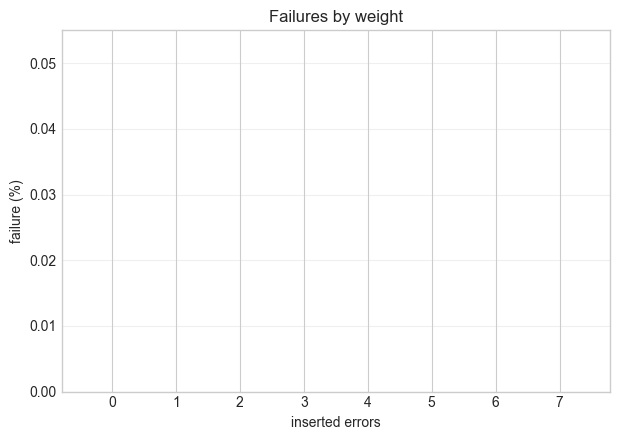

In [95]:
failure_by_weight = exact_weight_trials.groupby("inserted_component_errors", as_index=False).agg(
    episodes=("success", "size"),
    failure_rate=("success", lambda values: 1.0 - float(np.mean(values))),
    mean_residual_errors=("residual_weight", "mean"),
    mean_final_syndrome_weight=("final_syndrome_weight", "mean"),
)
display(failure_by_weight.style.format({
    "failure_rate": "{:.1%}",
    "mean_residual_errors": "{:.2f}",
    "mean_final_syndrome_weight": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(6.3, 4.5))
ax.bar(
    failure_by_weight["inserted_component_errors"].astype(str),
    100 * failure_by_weight["failure_rate"],
    color="indianred",
)
ax.set_title("Failures by weight")
ax.set_xlabel("inserted errors")
ax.set_ylabel("failure (%)")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Harder diagnostics: what kind of correction is learned?

The previous cells measure success rates. Here we inspect the *mechanism* of the correction: how many qubits the decoder flips, how many of those flips hit real errors, how many create new residual errors, and whether failures are caused by insufficient decoding steps. These tests are intentionally more detailed than the model-selection score.


In [96]:
@torch.no_grad()
def evaluate_model_with_correction_accounting(model, config, p_error, episodes, seed, max_steps=None):
    """Evaluate the policy while recording how the correction changes the error pattern."""
    h = utils.to_csr_binary(check_matrix)
    rng = np.random.default_rng(seed)
    rows = []
    step_limit = config.max_steps if max_steps is None else int(max_steps)
    eval_config = replace(config, max_steps=step_limit)

    for episode in range(episodes):
        error = utils.random_component_error(h.shape[1], rng, p=p_error, min_weight=0, max_weight=None)
        initial_syndrome = utils.binary_syndrome(h, error)
        env = utils.CSSCorrectionEnv(h, max_steps=eval_config.max_steps, seed=seed + episode, allow_stop_when_nonzero=False)
        env.reset(error=error)

        done = False
        steps = 0
        while not done:
            action = model.greedy_action(env.node_features(DEVICE), env.action_mask(DEVICE))
            _, _, done, _ = env.step(action)
            steps += 1

        correction = env.correction.astype(np.uint8)
        residual = (env.error + correction) % 2
        correction_hits = int(np.logical_and(error == 1, correction == 1).sum())
        false_positive_flips = int(np.logical_and(error == 0, correction == 1).sum())
        missed_original_errors = int(np.logical_and(error == 1, correction == 0).sum())
        residual_weight = int(residual.sum())
        success = int(env.syndrome.sum()) == 0

        rows.append({
            "p_error": p_error,
            "episode": episode,
            "max_steps": step_limit,
            "initial_error_weight": int(error.sum()),
            "initial_syndrome_weight": int(initial_syndrome.sum()),
            "correction_weight": int(correction.sum()),
            "correction_hits": correction_hits,
            "false_positive_flips": false_positive_flips,
            "missed_original_errors": missed_original_errors,
            "residual_weight": residual_weight,
            "final_syndrome_weight": int(env.syndrome.sum()),
            "net_errors_removed": int(error.sum()) - residual_weight,
            "steps": steps,
            "syndrome_cleared": success,
            "no_residual_error": residual_weight == 0,
            "ended_at_step_limit_with_syndrome": bool((not success) and steps >= step_limit),
        })
    return pd.DataFrame(rows)


COMPLEX_ERROR_RATES = np.array([0.005, 0.015, 0.03, 0.06, 0.09])
COMPLEX_EPISODES = 160 if BUDGET == "quick" else 400
complex_trials = pd.concat(
    [evaluate_model_with_correction_accounting(best_model, best_config_object, float(p), COMPLEX_EPISODES, 70_000 + i) for i, p in enumerate(COMPLEX_ERROR_RATES)],
    ignore_index=True,
)

complex_summary = complex_trials.groupby("p_error", as_index=False).agg(
    episodes=("syndrome_cleared", "size"),
    mean_inserted_errors=("initial_error_weight", "mean"),
    mean_initial_syndrome_weight=("initial_syndrome_weight", "mean"),
    syndrome_cleared_rate=("syndrome_cleared", "mean"),
    no_residual_error_rate=("no_residual_error", "mean"),
    mean_correction_weight=("correction_weight", "mean"),
    mean_false_positive_flips=("false_positive_flips", "mean"),
    mean_missed_original_errors=("missed_original_errors", "mean"),
    mean_residual_errors=("residual_weight", "mean"),
    mean_net_errors_removed=("net_errors_removed", "mean"),
    step_limit_failure_rate=("ended_at_step_limit_with_syndrome", "mean"),
)
display(complex_summary.style.format({
    "p_error": "{:.3%}",
    "mean_inserted_errors": "{:.2f}",
    "mean_initial_syndrome_weight": "{:.2f}",
    "syndrome_cleared_rate": "{:.1%}",
    "no_residual_error_rate": "{:.1%}",
    "mean_correction_weight": "{:.2f}",
    "mean_false_positive_flips": "{:.2f}",
    "mean_missed_original_errors": "{:.2f}",
    "mean_residual_errors": "{:.2f}",
    "mean_net_errors_removed": "{:.2f}",
    "step_limit_failure_rate": "{:.1%}",
}))


,p_error,episodes,mean_inserted_errors,mean_initial_syndrome_weight,syndrome_cleared_rate,no_residual_error_rate,mean_correction_weight,mean_false_positive_flips,mean_missed_original_errors,mean_residual_errors,mean_net_errors_removed,step_limit_failure_rate
0,0.500%,400,0.38,1.11,100.0%,100.0%,0.38,0.00,0.00,0.00,0.38,0.0%
1,1.500%,400,1.04,2.86,100.0%,99.5%,1.04,0.02,0.02,0.04,1.00,0.0%
2,3.000%,400,2.16,5.51,100.0%,96.2%,2.17,0.17,0.15,0.32,1.84,0.0%
3,6.000%,400,4.43,9.86,100.0%,68.5%,4.41,1.43,1.46,2.88,1.55,0.0%
4,9.000%,400,6.42,12.60,100.0%,41.0%,5.92,3.04,3.54,6.57,-0.14,0.0%


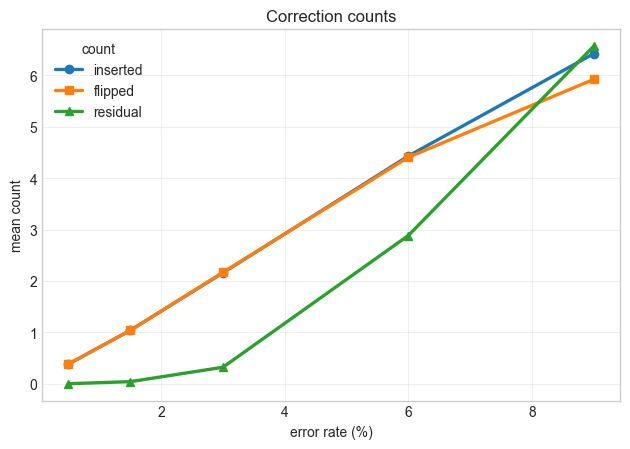

In [97]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
x = complex_summary["p_error"] * 100
ax.plot(x, complex_summary["mean_inserted_errors"], marker="o", linewidth=2.4, label="inserted")
ax.plot(x, complex_summary["mean_correction_weight"], marker="s", linewidth=2.4, label="flipped")
ax.plot(x, complex_summary["mean_residual_errors"], marker="^", linewidth=2.4, label="residual")
ax.set_title("Correction counts")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean count")
ax.grid(True, alpha=0.3)
ax.legend(title="count")
plt.tight_layout()
plt.show()


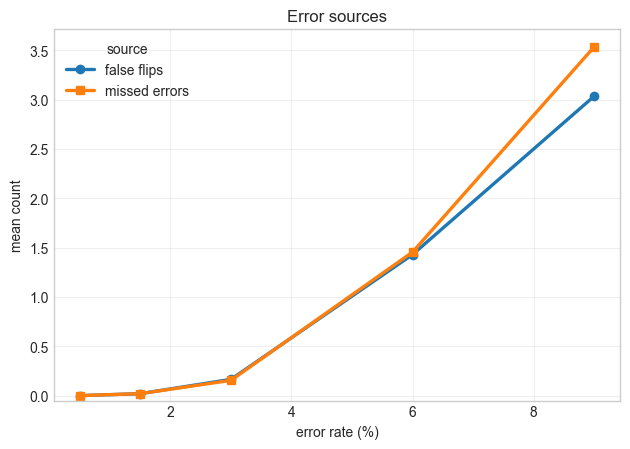

In [98]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(complex_summary["p_error"] * 100, complex_summary["mean_false_positive_flips"], marker="o", linewidth=2.4, label="false flips")
ax.plot(complex_summary["p_error"] * 100, complex_summary["mean_missed_original_errors"], marker="s", linewidth=2.4, label="missed errors")
ax.set_title("Error sources")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean count")
ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.3)
ax.legend(title="source")
plt.tight_layout()
plt.show()


## 12. Syndrome-weight difficulty

The syndrome weight is what the decoder actually observes. This diagnostic asks whether large measured syndromes are systematically harder, or whether the policy mainly struggles because different errors can share similar syndromes.


In [99]:
syndrome_bins = [-0.5, 0.5, 2.5, 4.5, 6.5, 8.5, np.inf]
syndrome_labels = ["0", "1-2", "3-4", "5-6", "7-8", "9+"]
complex_trials["initial_syndrome_weight_bin"] = pd.cut(
    complex_trials["initial_syndrome_weight"],
    bins=syndrome_bins,
    labels=syndrome_labels,
)
syndrome_difficulty = complex_trials.groupby("initial_syndrome_weight_bin", observed=True, as_index=False).agg(
    episodes=("syndrome_cleared", "size"),
    mean_inserted_errors=("initial_error_weight", "mean"),
    syndrome_cleared_rate=("syndrome_cleared", "mean"),
    no_residual_error_rate=("no_residual_error", "mean"),
    mean_residual_errors=("residual_weight", "mean"),
    mean_steps=("steps", "mean"),
)
display(syndrome_difficulty.style.format({
    "mean_inserted_errors": "{:.2f}",
    "syndrome_cleared_rate": "{:.1%}",
    "no_residual_error_rate": "{:.1%}",
    "mean_residual_errors": "{:.2f}",
    "mean_steps": "{:.2f}",
}))


,initial_syndrome_weight_bin,episodes,mean_inserted_errors,syndrome_cleared_rate,no_residual_error_rate,mean_residual_errors,mean_steps
0,0,459,0.00,100.0%,100.0%,0.00,1.00
1,3-4,435,1.10,100.0%,100.0%,0.00,1.10
2,5-6,230,2.17,100.0%,97.0%,0.20,2.17
3,7-8,164,3.59,100.0%,85.4%,1.22,3.57
4,9+,712,5.91,100.0%,51.1%,5.17,5.65


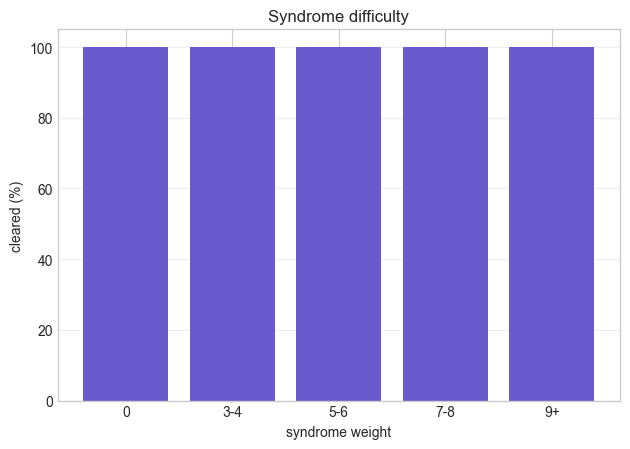

In [100]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.bar(
    syndrome_difficulty["initial_syndrome_weight_bin"].astype(str),
    100 * syndrome_difficulty["syndrome_cleared_rate"],
    color="slateblue",
)
ax.set_title("Syndrome difficulty")
ax.set_xlabel("syndrome weight")
ax.set_ylabel("cleared (%)")
ax.set_ylim(0, 105)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Hardness map over noise level and inserted weight

A single average can hide where the decoder actually breaks. This heatmap bins trials by both the physical error rate and the sampled error weight, showing which regimes are easy and which are outside the trained policy's comfort zone.


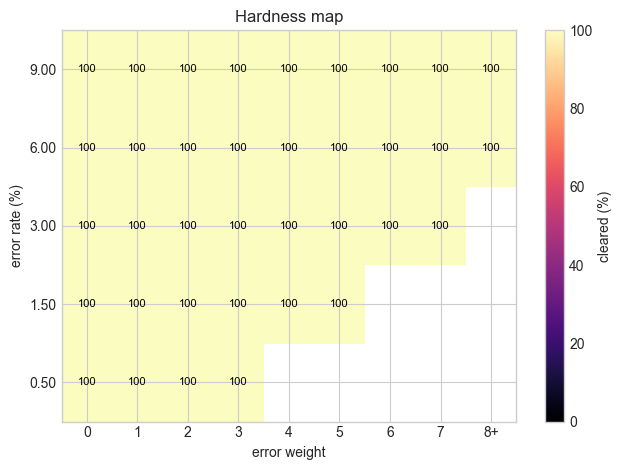

In [101]:
hardness_trials = complex_trials.copy()
hardness_trials["error_weight_bucket"] = hardness_trials["initial_error_weight"].clip(upper=8)
hardness_trials["error_weight_bucket"] = hardness_trials["error_weight_bucket"].astype(int).astype(str)
hardness_trials.loc[hardness_trials["initial_error_weight"] >= 8, "error_weight_bucket"] = "8+"

hardness = hardness_trials.pivot_table(
    index="p_error",
    columns="error_weight_bucket",
    values="syndrome_cleared",
    aggfunc="mean",
    observed=True,
).sort_index()
ordered_columns = [str(i) for i in range(8)] + ["8+"]
hardness = hardness.reindex(columns=[col for col in ordered_columns if col in hardness.columns])

fig, ax = plt.subplots(figsize=(6.5, 4.8))
image = ax.imshow(100 * hardness.values, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=100)
ax.set_xticks(range(len(hardness.columns)))
ax.set_xticklabels(hardness.columns)
ax.set_yticks(range(len(hardness.index)))
ax.set_yticklabels([f"{100*p:.2f}" for p in hardness.index])
ax.set_title("Hardness map")
ax.set_xlabel("error weight")
ax.set_ylabel("error rate (%)")
for i in range(hardness.shape[0]):
    for j in range(hardness.shape[1]):
        value = hardness.values[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{100*value:.0f}", ha="center", va="center", color="white" if value < 0.65 else "black", fontsize=8)
fig.colorbar(image, ax=ax, label="cleared (%)")
plt.tight_layout()
plt.show()


## 14. Step-limit sensitivity

The decoder acts one qubit at a time, so the allowed number of correction steps matters. This test reuses the same trained policy but changes the environment step cap during evaluation. If performance saturates early, the policy is decisive; if it keeps improving, failures were partly caused by stopping too soon.


In [102]:
STEP_LIMITS = [2, 4, 6, 8, best_config_object.max_steps, 12, 16]
STEP_LIMITS = sorted(set(limit for limit in STEP_LIMITS if limit > 0))
STEP_LIMIT_EPISODES = 100 if BUDGET == "quick" else 250
STEP_LIMIT_ERROR_RATE = 0.06

step_limit_trials = pd.concat(
    [evaluate_model_with_correction_accounting(best_model, best_config_object, STEP_LIMIT_ERROR_RATE, STEP_LIMIT_EPISODES, 80_000 + limit, max_steps=limit) for limit in STEP_LIMITS],
    ignore_index=True,
)
step_limit_summary = step_limit_trials.groupby("max_steps", as_index=False).agg(
    episodes=("syndrome_cleared", "size"),
    syndrome_cleared_rate=("syndrome_cleared", "mean"),
    no_residual_error_rate=("no_residual_error", "mean"),
    mean_residual_errors=("residual_weight", "mean"),
    step_limit_failure_rate=("ended_at_step_limit_with_syndrome", "mean"),
    mean_steps_used=("steps", "mean"),
)
display(step_limit_summary.style.format({
    "syndrome_cleared_rate": "{:.1%}",
    "no_residual_error_rate": "{:.1%}",
    "mean_residual_errors": "{:.2f}",
    "step_limit_failure_rate": "{:.1%}",
    "mean_steps_used": "{:.2f}",
}))


,max_steps,episodes,syndrome_cleared_rate,no_residual_error_rate,mean_residual_errors,step_limit_failure_rate,mean_steps_used
0,2,250,20.0%,19.6%,2.94,80.0%,1.94
1,4,250,65.2%,62.0%,2.11,34.8%,3.28
2,6,250,85.2%,69.6%,2.57,14.8%,4.07
3,8,250,96.4%,75.2%,2.24,3.6%,4.18
4,12,250,100.0%,66.0%,3.11,0.0%,4.53
5,16,250,100.0%,75.6%,2.47,0.0%,4.16


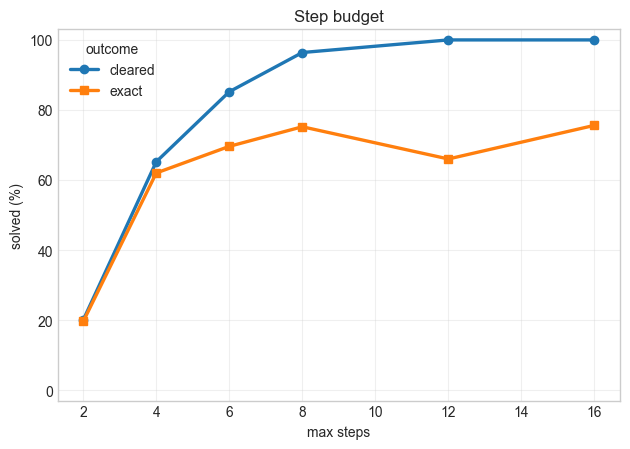

In [103]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(step_limit_summary["max_steps"], 100 * step_limit_summary["syndrome_cleared_rate"], marker="o", linewidth=2.4, label="cleared")
ax.plot(step_limit_summary["max_steps"], 100 * step_limit_summary["no_residual_error_rate"], marker="s", linewidth=2.4, label="exact")
ax.set_title("Step budget")
ax.set_xlabel("max steps")
ax.set_ylabel("solved (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.3)
ax.legend(title="outcome")
plt.tight_layout()
plt.show()


## 15. Exact-weight by step-limit heatmap

This final stress test removes randomness in the error weight and changes the step limit at the same time. It is useful for reading the decoder as an algorithm: low weights should need few steps, while high weights reveal whether the policy runs out of time or chooses poor flips.


In [104]:
GRID_WEIGHTS = list(range(0, min(9, check_matrix.shape[1] + 1)))
GRID_STEP_LIMITS = [2, 4, 6, 8, best_config_object.max_steps, 12, 16]
GRID_STEP_LIMITS = sorted(set(GRID_STEP_LIMITS))
GRID_EPISODES = 50 if BUDGET == "quick" else 150

def evaluate_exact_weight_with_step_limit(weight, step_limit, episodes, seed):
    h = utils.to_csr_binary(check_matrix)
    rng = np.random.default_rng(seed)
    rows = []
    for episode in range(episodes):
        error = sample_exact_weight_component_error(h.shape[1], weight, rng)
        env = utils.CSSCorrectionEnv(h, max_steps=step_limit, seed=seed + episode, allow_stop_when_nonzero=False)
        env.reset(error=error)
        done = False
        while not done:
            action = best_model.greedy_action(env.node_features(DEVICE), env.action_mask(DEVICE))
            _, _, done, _ = env.step(action)
        residual = (env.error + env.correction) % 2
        rows.append({
            "inserted_component_errors": weight,
            "max_steps": step_limit,
            "syndrome_cleared": int(env.syndrome.sum()) == 0,
            "residual_weight": int(residual.sum()),
        })
    return pd.DataFrame(rows)

exact_grid_trials = []
for weight in GRID_WEIGHTS:
    for step_limit in GRID_STEP_LIMITS:
        exact_grid_trials.append(evaluate_exact_weight_with_step_limit(weight, step_limit, GRID_EPISODES, 90_000 + 100 * weight + step_limit))
exact_grid_trials = pd.concat(exact_grid_trials, ignore_index=True)
exact_grid = exact_grid_trials.pivot_table(
    index="inserted_component_errors",
    columns="max_steps",
    values="syndrome_cleared",
    aggfunc="mean",
)
display((100 * exact_grid).style.format("{:.1f}"))


max_steps,2,4,6,8,12,16
inserted_component_errors,,,,,,
0,100.0,100.0,100.0,100.0,100.0,100.0
1,100.0,100.0,100.0,100.0,100.0,100.0
2,100.0,100.0,100.0,100.0,100.0,100.0
3,0.0,100.0,100.0,100.0,100.0,100.0
4,0.0,96.0,100.0,100.0,100.0,100.0
5,0.0,0.7,96.0,100.0,100.0,100.0
6,0.0,6.7,87.3,98.0,100.0,100.0
7,0.0,0.7,14.0,84.0,100.0,100.0
8,0.0,2.0,38.7,85.3,100.0,100.0


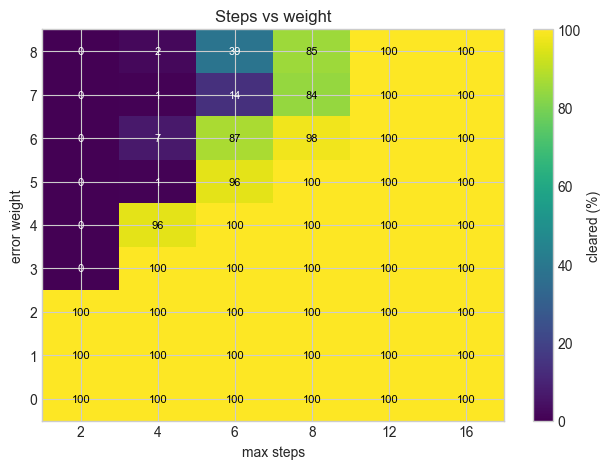

In [105]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
image = ax.imshow(100 * exact_grid.values, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=100)
ax.set_xticks(range(len(exact_grid.columns)))
ax.set_xticklabels(exact_grid.columns)
ax.set_yticks(range(len(exact_grid.index)))
ax.set_yticklabels(exact_grid.index)
ax.set_title("Steps vs weight")
ax.set_xlabel("max steps")
ax.set_ylabel("error weight")
for i in range(exact_grid.shape[0]):
    for j in range(exact_grid.shape[1]):
        value = exact_grid.values[i, j]
        ax.text(j, i, f"{100*value:.0f}", ha="center", va="center", color="white" if value < 0.65 else "black", fontsize=8)
fig.colorbar(image, ax=ax, label="cleared (%)")
plt.tight_layout()
plt.show()


## 16. Accuracy versus training cost

The last diagnostic checks whether the chosen model is simply the largest or slowest one. A good practical choice should sit high in validation score without requiring an unreasonable amount of training time.


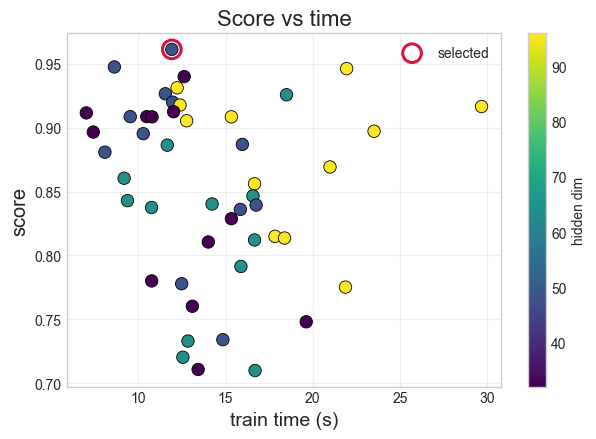

In [113]:
fig, ax = plt.subplots(figsize=(6.3, 4.5))
scatter = ax.scatter(
    ranked_results["train_seconds"],
    ranked_results["score"],
    s=80,
    c=ranked_results["hidden_dim"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.6,
)
ax.scatter(
    [best_config["train_seconds"]],
    [best_config["score"]],
    s=180,
    facecolors="none",
    edgecolors="crimson",
    linewidth=2.2,
    label="selected",
)
ax.set_title("Score vs time", fontsize=16)
ax.set_xlabel("train time (s)", fontsize=14)
ax.set_ylabel("score", fontsize=14.5)
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(scatter, ax=ax, label="hidden dim")
plt.tight_layout()
plt.show()


## 17. Learning curves for the selected model

These curves show whether the selected decoder learned smoothly. The imitation curve measures agreement with the exact small-code teacher, while the RL curve measures whether actor-critic fine-tuning preserves or improves syndrome clearing.


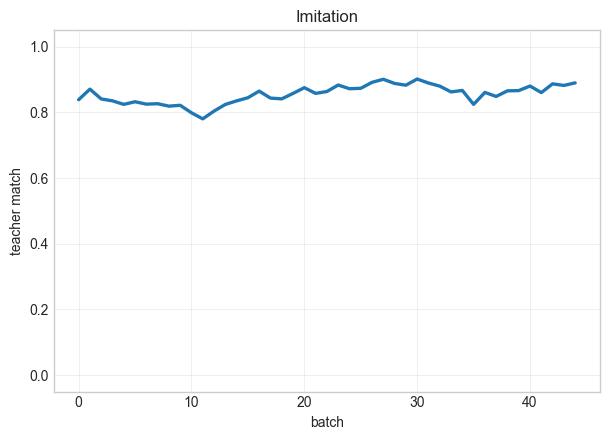

In [107]:
best_imitation = imitation_all[imitation_all["config_name"] == best_name]
best_rl = rl_all[rl_all["config_name"] == best_name]

fig, ax = plt.subplots(figsize=(6.2, 4.5))
ax.plot(best_imitation["batch"], best_imitation["teacher_action_accuracy"].rolling(5, min_periods=1).mean(), linewidth=2.4)
ax.set_title("Imitation")
ax.set_xlabel("batch")
ax.set_ylabel("teacher match")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


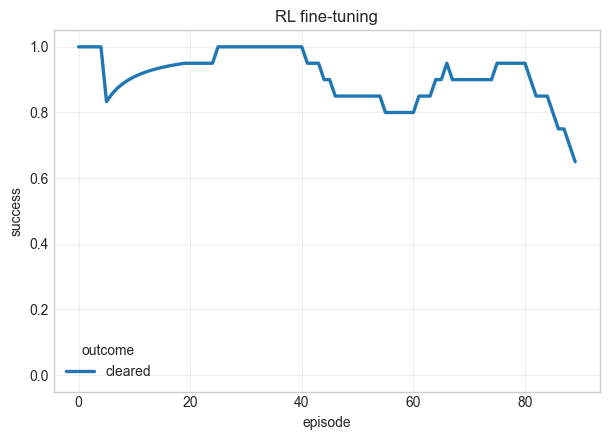

In [108]:
fig, ax = plt.subplots(figsize=(6.2, 4.5))
ax.plot(best_rl["episode"], best_rl["success"].rolling(20, min_periods=1).mean(), linewidth=2.4, label="cleared")
ax.set_title("RL fine-tuning")
ax.set_xlabel("episode")
ax.set_ylabel("success")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(title="outcome")
plt.tight_layout()
plt.show()


## 18. Export the selected configuration

The selected configuration is saved so that `tests.ipynb` can train and evaluate the same model family on the BB-code experiments.


In [109]:
ranked_results.to_csv(OUTPUT_DIR / "search_results.csv", index=False)
evaluation_by_rate.to_csv(OUTPUT_DIR / "evaluation_by_rate.csv", index=False)
(OUTPUT_DIR / "best_config.json").write_text(json.dumps(best_config, indent=2), encoding="utf-8")
if TASK == "medium-bb-lite":
    TESTS_COMPAT_CONFIG.write_text(json.dumps(best_config, indent=2), encoding="utf-8")

display(pd.DataFrame([best_config]))
print(f"Primary export: {OUTPUT_DIR / 'best_config.json'}")
if TASK == "medium-bb-lite":
    print(f"tests.ipynb compatibility export: {TESTS_COMPAT_CONFIG}")


,name,hidden_dim,layers,lr,imitation_batches,imitation_batch_size,rl_episodes,gamma,entropy_coef,value_coef,...,seed,score,mean_success_rate,mean_exact_rate,mean_residual_weight,mean_final_syndrome_weight,mean_steps,final_imitation_accuracy,final_rl_success,train_seconds
0,medium-bb-lite_expanded_018,48,3,0.0007,45,18,90,0.97,0.001,0.5,...,1018,0.961333,1.0,0.975,0.15,0.0,1.616667,0.914286,0.0,11.913624


Primary export: training_results\medium-bb-lite_expanded\best_config.json
tests.ipynb compatibility export: rl_tests\results_notebooks\medium-bb-lite_quick\best_config.json


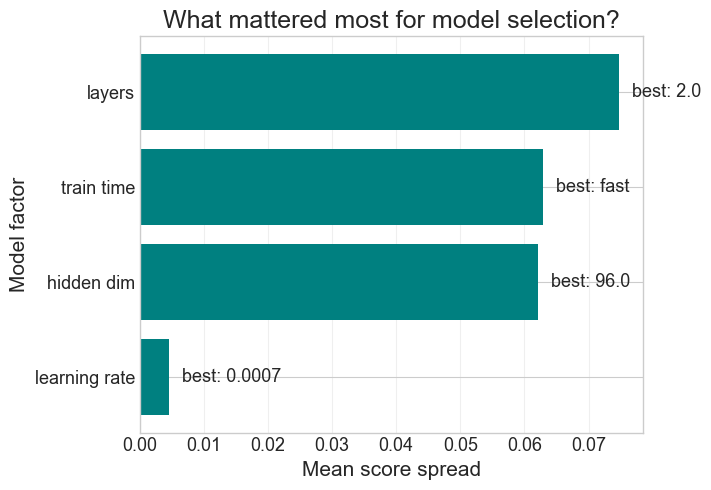

,factor,score_spread,best_value
2,learning rate,0.004507,0.0007
0,hidden dim,0.062146,96.0
3,train time,0.062880,fast
1,layers,0.074776,2.0


In [120]:
# Hyperparameter / cost importance by score spread.
# For each factor, compute the mean score at each value.
# The spread is the difference between the best and worst mean score.
# Larger spread means that factor mattered more for model selection.

importance_source = ranked_results.copy()

# Make training time easier to interpret by binning it into three groups.
importance_source["train time"] = pd.qcut(
    importance_source["train_seconds"],
    q=3,
    labels=["fast", "medium", "slow"],
)

factors = {
    "hidden dim": "hidden_dim",
    "layers": "layers",
    "learning rate": "lr",
    "train time": "train time",
}

importance_rows = []

for label, column in factors.items():
    grouped = (
        importance_source
        .groupby(column, as_index=False, observed=True)
        .agg(
            mean_score=("score", "mean"),
            n_models=("score", "size"),
        )
        .sort_values("mean_score", ascending=False)
    )

    best_value = grouped.iloc[0][column]
    spread = grouped["mean_score"].max() - grouped["mean_score"].min()

    importance_rows.append({
        "factor": label,
        "score_spread": spread,
        "best_value": best_value,
    })

importance_df = (
    pd.DataFrame(importance_rows)
    .sort_values("score_spread", ascending=True)
)

fig, ax = plt.subplots(figsize=(7.2, 5.0))

ax.barh(
    importance_df["factor"],
    importance_df["score_spread"],
    color="teal",
)

for i, row in importance_df.reset_index(drop=True).iterrows():
    ax.text(
        row["score_spread"] + 0.002,
        i,
        f"best: {row['best_value']}",
        va="center",
        fontsize=13,
    )

ax.set_title("What mattered most for model selection?", fontsize=18)
ax.set_xlabel("Mean score spread", fontsize=15)
ax.set_ylabel("Model factor", fontsize=15)

ax.tick_params(axis="both", labelsize=13)
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(importance_df)
